# Obligatorio - Inteligencia Artificial Generativa  
# WGAN-GP: Una versión mejorada da las GAN "Vanilla"
---

- Diciembre 2025  
- Enrique Oliva - 214205

## Introducción
---

La presente notebook constituye una demostración empírica de las mejoras que introduce WGAN-GP a sus versiones predecesoras, particularmente mediante la comparación de tres arquitecturas de GANs: Vanilla GAN, WGAN y WGAN-GP.

Al comienzo se demuestra el problema de saturación del discriminador que causa gradientes que desaparecen: D(real)→1, D(fake)→0, resultando en un colapso de modo o mode collapse.

WGAN (Arjovsky et al., 2017) soluciona esto reemplazando BCE loss por distancia Wasserstein con un crítico sin sigmoid, pero introduce clipping de los pesos (o weight clipping) que fuerza los pesos a ±0.01 causando distribución bimodal y gradientes explosivos.

WGAN-GP (Gulrajani et al., 2017) reemplaza el clipping por un gradient penalty (λ=10) que fuerza la restricción de Lipschitz (concepto a explicar más abajo) de forma suave, permitiendo distribución natural de pesos y gradientes estables (varianza 691× mejor que WGAN).

Los tres modelos se entrenan sobre CIFAR-10 con arquitecturas DCGAN compartidas. La sección de evaluación demuestra progresivamente cada problema y su solución mediante visualizaciones de: saturación D(real)/D(fake), distancia Wasserstein, distribución de pesos (bimodal vs Gaussiana), normas de gradientes, evolución del GP, y calidad de muestras generadas.

Nota sobre "Vanilla GAN": El paper original de Goodfellow et al. (2014) usó MLPs con activaciones Maxout y Dropout. Siguiendo la práctica estándar moderna, se implementó la Vanilla GAN como GAN con BCE loss usando arquitectura DCGAN (CNNs con BatchNorm), ya que el término se refiere conceptualmente a la función objetivo original, no a la arquitectura específica de 2014. Esto permite una comparación justa de las funciones de pérdida manteniendo la arquitectura constante.

Referencias:
- [Generative Adversarial Nets (Goodfellow et al., 2014)](https://arxiv.org/abs/1406.2661)
- [Wasserstein GAN (Arjovsky et al., 2017)](https://arxiv.org/abs/1701.07875)
- [Improved Training of Wasserstein GANs (Gulrajani et al., 2017)](https://arxiv.org/abs/1704.00028)

## Configuración general
---

### Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime
import wandb

### Semilla para reproducibilidad

In [2]:
torch.manual_seed(42)
np.random.seed(42)

### Configuración de dispositivo

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070


### Configuración de salidas y logging

In [4]:
os.environ["WANDB_SILENT"] = "true"

BASE_OUTPUT_DIR = "./outputs"
EXPERIMENT_NAME = "wgan_comparison"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = f"{BASE_OUTPUT_DIR}/{EXPERIMENT_NAME}_{TIMESTAMP}"
MODELS_DIR = f"{RESULTS_DIR}/models"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
DATA_DIR = "./data"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

USE_WANDB = True
WANDB_PROJECT = "Obligatorio de IA Generativa 2025"
WANDB_ENTITY = "eo214205-ort"
WANDB_GROUP = datetime.now().strftime("%d/%m/%y - %H:%M")

## Hiperparámetros
---

### Hiperparámetros comunes a los 3 modelos

In [5]:
BATCH_SIZE = 64
IMAGE_SIZE = 32
NUM_CHANNELS = 3
LATENT_DIM = 128
GENERATOR_FEATURES = 128
NUM_EPOCHS = 400

### Vanilla GAN

In [6]:
VANILLA_LR = 0.01
VANILLA_MOMENTUM = 0.9
VANILLA_DISCRIMINATOR_FEATURES = 128

### WGAN

In [7]:
WGAN_LR = 5e-5
WGAN_CLIP = 0.01
WGAN_CRITIC_FEATURES = 128
WGAN_CRITIC_ITERATIONS = 5

### WGAN-GP

In [8]:
WGANGP_LR = 1e-4
WGANGP_LAMBDA = 10
WGANGP_BETAS = (0.0, 0.9)
WGANGP_CRITIC_FEATURES = 128
WGANGP_CRITIC_ITERATIONS = 5

## Carga y análisis del dataset
---

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=transform
)

dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
)

print(f"Dataset: CIFAR-10")
print(f"Imágenes: {len(train_dataset)}")
print(f"Batches/época: {len(dataloader)}")

Files already downloaded and verified
Dataset: CIFAR-10
Imágenes: 50000
Batches/época: 781


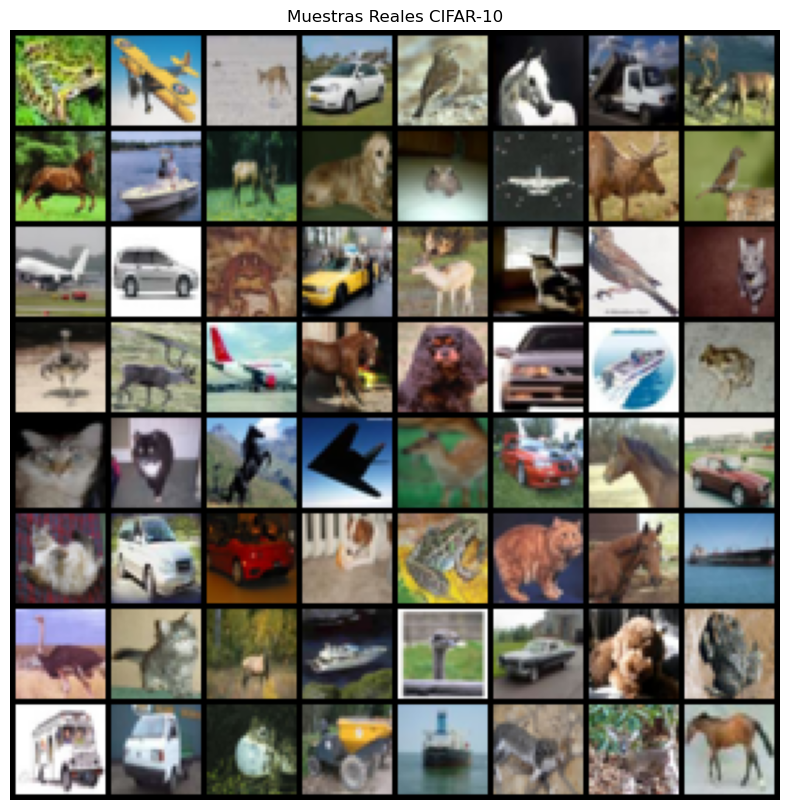

In [10]:
real_batch = next(iter(dataloader))[0]
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Muestras Reales CIFAR-10")
plt.imshow(np.transpose(
    vutils.make_grid(real_batch[:64], padding=2, normalize=True, nrow=8).cpu(),
    (1, 2, 0)
))
plt.show()

## Implementación de los modelos
---



### Generador (compartido por las 3 variantes)

In [11]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_features, num_channels):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, num_features * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(num_features * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features * 4, num_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features * 2, num_features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features, num_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.BatchNorm2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, z):
        return self.main(z)

test_gen = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
test_z = torch.randn(1, LATENT_DIM, 1, 1, device=device)
test_out = test_gen(test_z)
del test_gen, test_z, test_out

### Discriminador Vanilla GAN

In [12]:
class VanillaDiscriminator(nn.Module):
    def __init__(self, num_channels, num_features):
        super(VanillaDiscriminator, self).__init__()
        
        self.main = nn.Sequential(
            nn.Conv2d(num_channels, num_features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features, num_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 2, num_features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
        
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.BatchNorm2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, x):
        return self.main(x).view(-1)

test_disc = VanillaDiscriminator(NUM_CHANNELS, VANILLA_DISCRIMINATOR_FEATURES).to(device)
test_img = torch.randn(1, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_out = test_disc(test_img)
del test_disc, test_img, test_out

### Discriminador (ahora Critic) WGAN/WGAN-GP

In [13]:
class Critic(nn.Module):
    def __init__(self, num_channels, num_features):
        super(Critic, self).__init__()
        
        self.main = nn.Sequential(
            nn.Conv2d(num_channels, num_features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features, num_features * 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 2, num_features * 4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 4, 1, 4, 1, 0, bias=False)
        )
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, x):
        return self.main(x).view(-1)

test_critic = Critic(NUM_CHANNELS, WGAN_CRITIC_FEATURES).to(device)
test_img = torch.randn(1, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_out = test_critic(test_img)
del test_critic, test_img, test_out

### Optimizador Vanilla GAN

In [14]:
def get_vanilla_optimizers(generator, discriminator):
    optimizer_G = optim.SGD(generator.parameters(), lr=VANILLA_LR, momentum=VANILLA_MOMENTUM)
    optimizer_D = optim.SGD(discriminator.parameters(), lr=VANILLA_LR, momentum=VANILLA_MOMENTUM)
    return optimizer_G, optimizer_D

### Optimizador WGAN

In [15]:
def get_wgan_optimizers(generator, critic):
    optimizer_G = optim.RMSprop(generator.parameters(), lr=WGAN_LR)
    optimizer_C = optim.RMSprop(critic.parameters(), lr=WGAN_LR)
    return optimizer_G, optimizer_C

### Optimizador WGAN-GP

In [16]:
def get_wgangp_optimizers(generator, critic):
    optimizer_G = optim.Adam(generator.parameters(), lr=WGANGP_LR, betas=WGANGP_BETAS)
    optimizer_C = optim.Adam(critic.parameters(), lr=WGANGP_LR, betas=WGANGP_BETAS)
    return optimizer_G, optimizer_C

### Loss Vanilla GAN

In [17]:
criterion_bce = nn.BCELoss()

### Loss WGAN

In [18]:
def wgan_critic_loss(critic_real, critic_fake):
    return -(critic_real - critic_fake)

def wgan_generator_loss(critic_fake):
    return -critic_fake

### Loss WGAN-GP

In [19]:
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    batch_size = real_samples.size(0)
    
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_samples)
    
    interpolated = alpha * real_samples + (1 - alpha) * fake_samples
    interpolated.requires_grad_(True)
    
    critic_interpolated = critic(interpolated)
    
    gradients = autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]
    
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    gradient_penalty = ((gradient_norm - 1) ** 2).mean()
    
    return gradient_penalty

def wgangp_critic_loss(critic_real, critic_fake, gp):
    return -(critic_real - critic_fake) + WGANGP_LAMBDA * gp

def wgangp_generator_loss(critic_fake):
    return -critic_fake

### Utilidades compartidas

In [20]:
class TrainingMetrics:
    def __init__(self):
        self.critic_losses = []
        self.generator_losses = []
        self.d_real_outputs = []
        self.d_fake_outputs = []
        self.gradient_norms = []
        self.gradient_penalties = []
        self.training_time = 0
        self.generated_samples = []
        self.iterations = []
    
    def log(self, iteration, c_loss, g_loss, d_real, d_fake):
        self.iterations.append(iteration)
        self.critic_losses.append(c_loss)
        self.generator_losses.append(g_loss)
        self.d_real_outputs.append(d_real)
        self.d_fake_outputs.append(d_fake)
    
    def log_gp(self, gp):
        self.gradient_penalties.append(gp)
    
    def log_gradients(self, critic_grads):
        total = sum(critic_grads.values())
        self.gradient_norms.append(total)
    
    def save_samples(self, samples):
        self.generated_samples.append(samples.detach().cpu())

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms[name] = param.grad.data.norm(2).item()
    return norms

def get_all_weights(model):
    weights = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            weights.extend(param.data.cpu().numpy().flatten())
    return np.array(weights)

## Entrenamiento de los modelos
---

### Entrenamiento Vanilla GAN

In [21]:
def train_vanilla_gan(dataloader, num_epochs, log_interval=100):
    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
                   name="Vanilla GAN", config={"modelo": "Vanilla GAN", "lr": VANILLA_LR, "momentum": VANILLA_MOMENTUM, "epocas": num_epochs})
    
    print(f"Entrenando Vanilla GAN: lr={VANILLA_LR}, momentum={VANILLA_MOMENTUM}, épocas={num_epochs}")
    
    generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
    discriminator = VanillaDiscriminator(NUM_CHANNELS, VANILLA_DISCRIMINATOR_FEATURES).to(device)
    optimizer_G, optimizer_D = get_vanilla_optimizers(generator, discriminator)
    
    metrics = TrainingMetrics()
    fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    start_time = time.time()
    iteration = 0
    
    for epoch in range(num_epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            optimizer_D.zero_grad()
            labels_real = torch.ones(batch_size, device=device)
            labels_fake = torch.zeros(batch_size, device=device)
            
            output_real = discriminator(real_images)
            d_loss_real = criterion_bce(output_real, labels_real)
            d_loss_real.backward()
            
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            output_fake = discriminator(fake_images.detach())
            d_loss_fake = criterion_bce(output_fake, labels_fake)
            d_loss_fake.backward()
            
            d_loss = d_loss_real + d_loss_fake
            optimizer_D.step()
            
            optimizer_G.zero_grad()
            output_fake_g = discriminator(fake_images)
            g_loss = criterion_bce(output_fake_g, labels_real)
            g_loss.backward()
            optimizer_G.step()
            
            if iteration % log_interval == 0:
                d_real = output_real.mean().item()
                d_fake = output_fake.mean().item()
                metrics.log(iteration, d_loss.item(), g_loss.item(), d_real, d_fake)
                metrics.log_gradients(get_gradient_norms(discriminator))
                
                if USE_WANDB:
                    wandb.log({"loss_D": d_loss.item(), "loss_G": g_loss.item(), "D_real": d_real, "D_fake": d_fake})
            
            iteration += 1
        
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            metrics.save_samples(fake_samples)
            if USE_WANDB:
                wandb.log({"samples": wandb.Image(vutils.make_grid(fake_samples[:16], normalize=True))})
        
        print(f"\rÉpoca {epoch+1}/{num_epochs}", end='', flush=True)
    
    print()
    metrics.training_time = time.time() - start_time
    if USE_WANDB:
        wandb.finish()
    
    print(f"Completado: {metrics.training_time/60:.2f} min")
    return generator, discriminator, metrics

In [22]:
vanilla_gen, vanilla_disc, vanilla_metrics = train_vanilla_gan(dataloader, NUM_EPOCHS)

Entrenando Vanilla GAN: lr=0.01, momentum=0.9, épocas=400
Época 400/400
Completado: 59.76 min


### Entrenamiento WGAN

In [23]:
def train_wgan(dataloader, num_epochs, log_interval=100):
    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
                   name=f"WGAN (c={WGAN_CLIP})", config={"modelo": "WGAN", "lr": WGAN_LR, "clip": WGAN_CLIP})
    
    print(f"Entrenando WGAN: lr={WGAN_LR}, c={WGAN_CLIP}, épocas={num_epochs}")
    
    generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
    critic = Critic(NUM_CHANNELS, WGAN_CRITIC_FEATURES).to(device)
    optimizer_G, optimizer_C = get_wgan_optimizers(generator, critic)
    
    metrics = TrainingMetrics()
    fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    start_time = time.time()
    iteration = 0
    
    for epoch in range(num_epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            for _ in range(WGAN_CRITIC_ITERATIONS):
                optimizer_C.zero_grad()
                
                z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
                fake_images = generator(z).detach()
                
                critic_real = critic(real_images).mean()
                critic_fake = critic(fake_images).mean()
                
                c_loss = wgan_critic_loss(critic_real, critic_fake)
                c_loss.backward()
                optimizer_C.step()
                
                for p in critic.parameters():
                    p.data.clamp_(-WGAN_CLIP, WGAN_CLIP)
            
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            g_loss = wgan_generator_loss(critic(fake_images).mean())
            g_loss.backward()
            optimizer_G.step()
            
            if iteration % log_interval == 0:
                c_real = critic_real.item()
                c_fake = critic_fake.item()
                metrics.log(iteration, c_loss.item(), g_loss.item(), c_real, c_fake)
                metrics.log_gradients(get_gradient_norms(critic))
                
                if USE_WANDB:
                    wandb.log({"loss_C": c_loss.item(), "loss_G": g_loss.item(), "C_real": c_real, "C_fake": c_fake})
            
            iteration += 1
        
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            metrics.save_samples(fake_samples)
            if USE_WANDB:
                wandb.log({"samples": wandb.Image(vutils.make_grid(fake_samples[:16], normalize=True))})
        
        print(f"\rÉpoca {epoch+1}/{num_epochs}", end='', flush=True)
    
    print()
    metrics.training_time = time.time() - start_time
    if USE_WANDB:
        wandb.finish()
    
    print(f"Completado: {metrics.training_time/60:.2f} min")
    return generator, critic, metrics

In [24]:
wgan_gen, wgan_critic, wgan_metrics = train_wgan(dataloader, NUM_EPOCHS)

Entrenando WGAN: lr=5e-05, c=0.01, épocas=400
Época 400/400
Completado: 165.37 min


### Entrenamiento WGAN-GP

In [25]:
def train_wgangp(dataloader, num_epochs, log_interval=100):
    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
                   name=f"WGAN-GP (λ={WGANGP_LAMBDA})", config={"modelo": "WGAN-GP", "lr": WGANGP_LR, "lambda": WGANGP_LAMBDA})
    
    print(f"Entrenando WGAN-GP: lr={WGANGP_LR}, λ={WGANGP_LAMBDA}, épocas={num_epochs}")
    
    generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
    critic = Critic(NUM_CHANNELS, WGANGP_CRITIC_FEATURES).to(device)
    optimizer_G, optimizer_C = get_wgangp_optimizers(generator, critic)
    
    metrics = TrainingMetrics()
    fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    start_time = time.time()
    iteration = 0
    
    for epoch in range(num_epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            for _ in range(WGANGP_CRITIC_ITERATIONS):
                optimizer_C.zero_grad()
                
                z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
                fake_images = generator(z)
                
                critic_real = critic(real_images).mean()
                critic_fake = critic(fake_images).mean()
                gp = compute_gradient_penalty(critic, real_images, fake_images, device)
                
                c_loss = wgangp_critic_loss(critic_real, critic_fake, gp)
                c_loss.backward()
                optimizer_C.step()
            
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            g_loss = wgangp_generator_loss(critic(fake_images).mean())
            g_loss.backward()
            optimizer_G.step()
            
            if iteration % log_interval == 0:
                c_real = critic_real.item()
                c_fake = critic_fake.item()
                metrics.log(iteration, c_loss.item(), g_loss.item(), c_real, c_fake)
                metrics.log_gp(gp.item())
                metrics.log_gradients(get_gradient_norms(critic))
                
                if USE_WANDB:
                    wandb.log({"loss_C": c_loss.item(), "loss_G": g_loss.item(), "C_real": c_real, "C_fake": c_fake, "GP": gp.item()})
            
            iteration += 1
        
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            metrics.save_samples(fake_samples)
            if USE_WANDB:
                wandb.log({"samples": wandb.Image(vutils.make_grid(fake_samples[:16], normalize=True))})
        
        print(f"\rÉpoca {epoch+1}/{num_epochs}", end='', flush=True)
    
    print()
    metrics.training_time = time.time() - start_time
    if USE_WANDB:
        wandb.finish()
    
    print(f"Completado: {metrics.training_time/60:.2f} min")
    return generator, critic, metrics

In [26]:
wgangp_gen, wgangp_critic, wgangp_metrics = train_wgangp(dataloader, NUM_EPOCHS)

Entrenando WGAN-GP: lr=0.0001, λ=10, épocas=400
Época 400/400
Completado: 334.07 min


## Evaluación de los modelos
---

### Vanilla GAN: Saturación del Discriminador

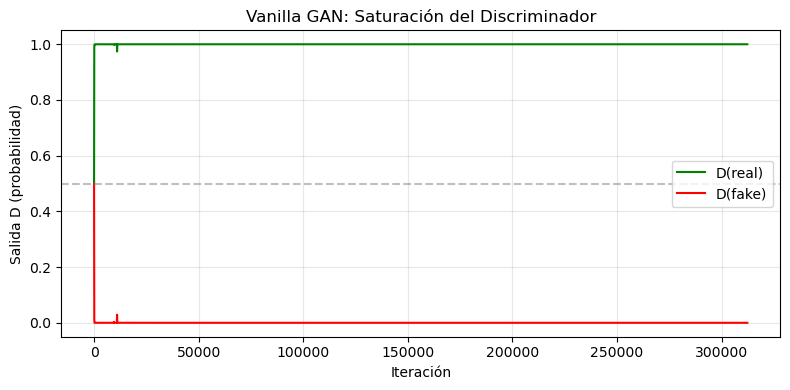

D(real) → 1.000, D(fake) → 0.000


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(vanilla_metrics.iterations, vanilla_metrics.d_real_outputs, label='D(real)', color='green', linewidth=1.5)
ax.plot(vanilla_metrics.iterations, vanilla_metrics.d_fake_outputs, label='D(fake)', color='red', linewidth=1.5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Iteración')
ax.set_ylabel('Salida D (probabilidad)')
ax.set_title('Vanilla GAN: Saturación del Discriminador')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/1_vanilla_saturation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"D(real) → {vanilla_metrics.d_real_outputs[-1]:.3f}, D(fake) → {vanilla_metrics.d_fake_outputs[-1]:.3f}")

### WGAN: Distancia Wasserstein

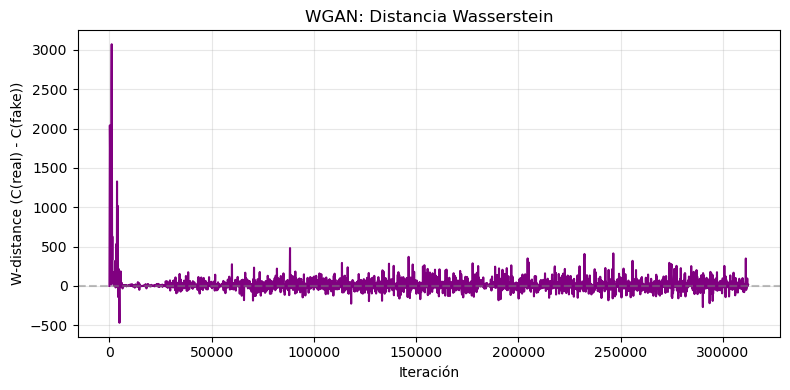

W-distance final: 16.1235


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

w_distance = [r - f for r, f in zip(wgan_metrics.d_real_outputs, wgan_metrics.d_fake_outputs)]
ax.plot(wgan_metrics.iterations, w_distance, color='purple', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Iteración')
ax.set_ylabel('W-distance (C(real) - C(fake))')
ax.set_title('WGAN: Distancia Wasserstein')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/2_wgan_wdistance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"W-distance final: {w_distance[-1]:.4f}")

### Comparación de los pesos entre Vanilla GAN y WGAN

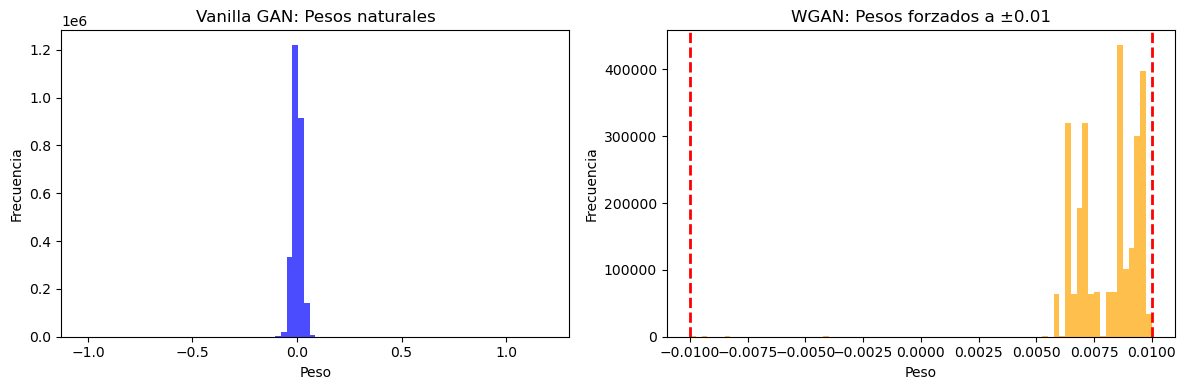

Vanilla: rango [-1.017, 1.193]
WGAN: rango [-0.010, 0.010]


In [ ]:
vanilla_weights = get_all_weights(vanilla_disc)
wgan_weights = get_all_weights(wgan_critic)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vanilla_weights, bins=80, color='blue', alpha=0.7)
axes[0].set_xlabel('Peso')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Vanilla GAN')

axes[1].hist(wgan_weights, bins=80, color='orange', alpha=0.7)
axes[1].axvline(x=-WGAN_CLIP, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=WGAN_CLIP, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Peso')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('WGAN')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/3_weight_clipping.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Vanilla: rango [{vanilla_weights.min():.3f}, {vanilla_weights.max():.3f}]")
print(f"WGAN: rango [{wgan_weights.min():.3f}, {wgan_weights.max():.3f}]")

### Comparación de gradientes

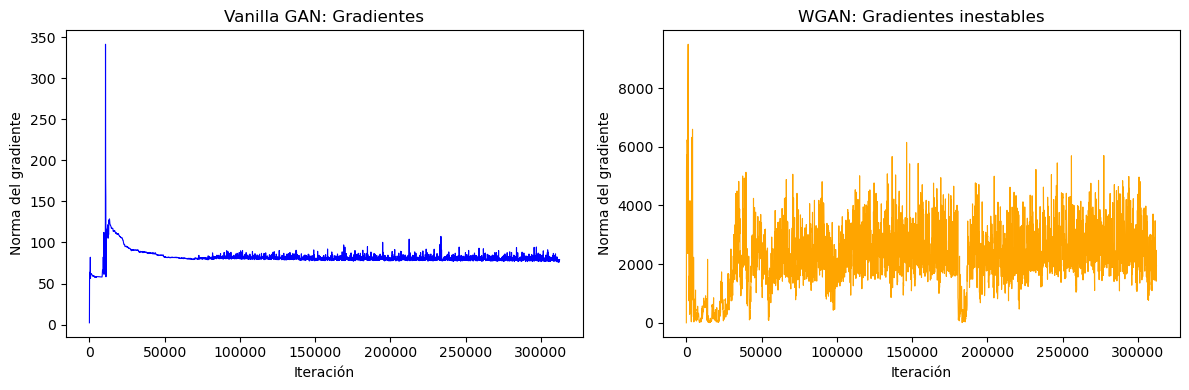

Varianza Vanilla: 92
Varianza WGAN: 1.13e+06


In [ ]:
ig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(vanilla_metrics.iterations, vanilla_metrics.gradient_norms, color='blue', linewidth=0.8)
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Norma del gradiente')
axes[0].set_title('Vanilla GAN')

axes[1].plot(wgan_metrics.iterations, wgan_metrics.gradient_norms, color='orange', linewidth=0.8)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Norma del gradiente')
axes[1].set_title('WGAN')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/4_gradient_instability.png', dpi=150, bbox_inches='tight')
plt.show()

vanilla_var = np.var(vanilla_metrics.gradient_norms)
wgan_var = np.var(wgan_metrics.gradient_norms)
print(f"Varianza Vanilla: {vanilla_var:.0f}")
print(f"Varianza WGAN: {wgan_var:.2e}")

### Comparación de los pesos entre WGAN y WGAN-GP

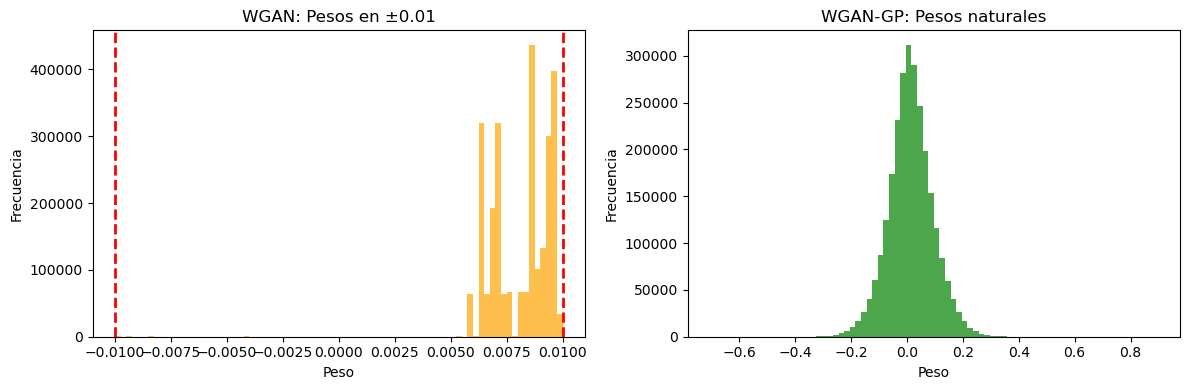

WGAN std: 0.0014
WGAN-GP std: 0.0802


In [ ]:
wgangp_weights = get_all_weights(wgangp_critic)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(wgan_weights, bins=80, color='orange', alpha=0.7)
axes[0].axvline(x=-WGAN_CLIP, color='red', linestyle='--', linewidth=2)
axes[0].axvline(x=WGAN_CLIP, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Peso')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'WGAN: Pesos en ±{WGAN_CLIP}')

axes[1].hist(wgangp_weights, bins=80, color='green', alpha=0.7)
axes[1].set_xlabel('Peso')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('WGAN-GP: Pesos naturales')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/5_wgangp_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"WGAN std: {wgan_weights.std():.4f}")
print(f"WGAN-GP std: {wgangp_weights.std():.4f}")

### Comparación de gradientes entre WGAN y WGAN-GP, y visualización del Gradient Penalty del WGAN-GP

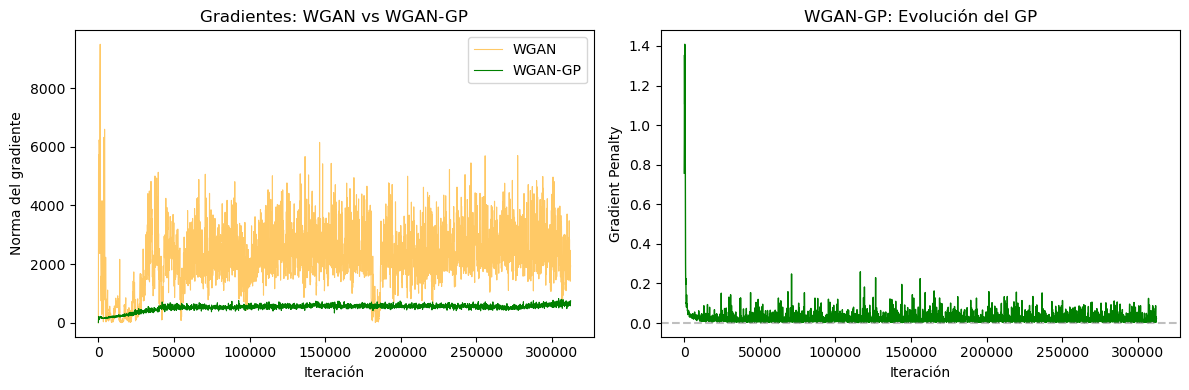

Varianza WGAN: 1.13e+06
Varianza WGAN-GP: 12468
GP final: 0.0232


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(wgan_metrics.iterations, wgan_metrics.gradient_norms, color='orange', alpha=0.6, linewidth=0.8, label='WGAN')
axes[0].plot(wgangp_metrics.iterations, wgangp_metrics.gradient_norms, color='green', linewidth=0.8, label='WGAN-GP')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Norma del gradiente')
axes[0].set_title('Gradientes: WGAN vs WGAN-GP')
axes[0].legend()

gp_iters = wgangp_metrics.iterations[:len(wgangp_metrics.gradient_penalties)]
axes[1].plot(gp_iters, wgangp_metrics.gradient_penalties, color='green', linewidth=1)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Gradient Penalty')
axes[1].set_title('WGAN-GP: Evolución del GP')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/6_wgangp_gradients.png', dpi=150, bbox_inches='tight')
plt.show()

wgan_var = np.var(wgan_metrics.gradient_norms)
wgangp_var = np.var(wgangp_metrics.gradient_norms)
print(f"Varianza WGAN: {wgan_var:.2e}")
print(f"Varianza WGAN-GP: {wgangp_var:.0f}")
print(f"GP final: {wgangp_metrics.gradient_penalties[-1]:.4f}")

### Muestras generadas

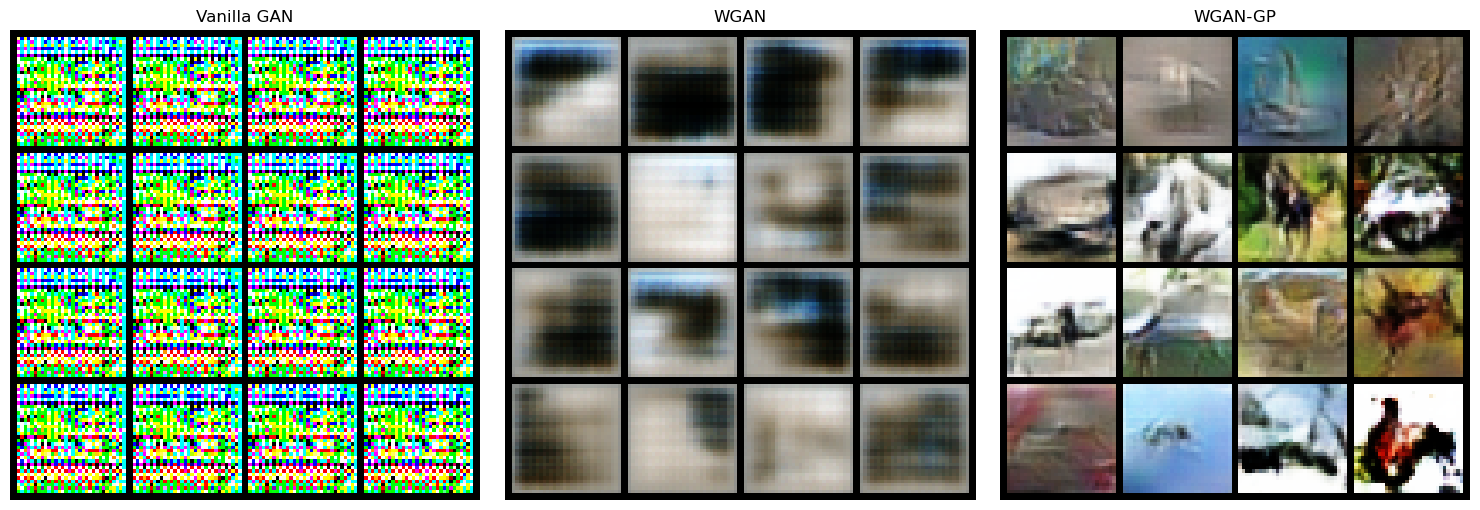

RESUMEN
Modelo       Tiempo     Var. Grad    Peso std  
--------------------------------------------------
Vanilla      59.8       92           0.0212    
WGAN         165.4      1.13e+06     0.0014    
WGAN-GP      334.1      12468        0.0802    


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

samples_v = vanilla_metrics.generated_samples[-1][:16]
grid_v = vutils.make_grid(samples_v, nrow=4, normalize=True, padding=2)
axes[0].imshow(np.transpose(grid_v.numpy(), (1, 2, 0)))
axes[0].set_title('Vanilla GAN')
axes[0].axis('off')

samples_w = wgan_metrics.generated_samples[-1][:16]
grid_w = vutils.make_grid(samples_w, nrow=4, normalize=True, padding=2)
axes[1].imshow(np.transpose(grid_w.numpy(), (1, 2, 0)))
axes[1].set_title('WGAN')
axes[1].axis('off')

samples_gp = wgangp_metrics.generated_samples[-1][:16]
grid_gp = vutils.make_grid(samples_gp, nrow=4, normalize=True, padding=2)
axes[2].imshow(np.transpose(grid_gp.numpy(), (1, 2, 0)))
axes[2].set_title('WGAN-GP')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/7_final_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("RESUMEN")

print(f"{'\nModelo':<12} {'Tiempo':<10} {'Var. Grad':<12} {'Peso std':<10}")

print(f"{'\nVanilla':<12} {vanilla_metrics.training_time/60:<10.1f} {np.var(vanilla_metrics.gradient_norms):<12.0f} {vanilla_weights.std():<10.4f}")
print(f"{'WGAN':<12} {wgan_metrics.training_time/60:<10.1f} {np.var(wgan_metrics.gradient_norms):<12.2e} {wgan_weights.std():<10.4f}")
print(f"{'WGAN-GP':<12} {wgangp_metrics.training_time/60:<10.1f} {np.var(wgangp_metrics.gradient_norms):<12.0f} {wgangp_weights.std():<10.4f}")

In [ ]:
print("RESUMEN COMPARATIVO")

print("\nTIEMPOS DE ENTRENAMIENTO:")
print(f"  Vanilla GAN: {vanilla_metrics.training_time/60:.2f} min")
print(f"  WGAN:        {wgan_metrics.training_time/60:.2f} min (5x critic iterations)")
print(f"  WGAN-GP:     {wgangp_metrics.training_time/60:.2f} min (5x critic iterations + GP)")

print("\nWASSERSTEIN DISTANCE FINAL (solo WGAN/WGAN-GP):")
wgan_final_w = wgan_metrics.d_real_outputs[-1] - wgan_metrics.d_fake_outputs[-1]
wgangp_final_w = wgangp_metrics.d_real_outputs[-1] - wgangp_metrics.d_fake_outputs[-1]
print(f"  WGAN:    {wgan_final_w:.4f}")
print(f"  WGAN-GP: {wgangp_final_w:.4f}")

print("\nDISTRIBUCIÓN DE PESOS:")
print(f"  Vanilla GAN: rango=[{vanilla_weights.min():.4f}, {vanilla_weights.max():.4f}], std={vanilla_weights.std():.4f}")
print(f"  WGAN:        rango=[{wgan_weights.min():.4f}, {wgan_weights.max():.4f}], std={wgan_weights.std():.4f}")
print(f"  WGAN-GP:     rango=[{wgangp_weights.min():.4f}, {wgangp_weights.max():.4f}], std={wgangp_weights.std():.4f}")

print("\nESTABILIDAD DE GRADIENTES (varianza):")
print(f"  Vanilla GAN: {np.var(vanilla_metrics.gradient_norms):.4f}")
print(f"  WGAN:        {np.var(wgan_metrics.gradient_norms):.4f}")
print(f"  WGAN-GP:     {np.var(wgangp_metrics.gradient_norms):.4f}")

print("\n" + "="*70)

RESUMEN COMPARATIVO

📊 TIEMPOS DE ENTRENAMIENTO:
  Vanilla GAN: 59.76 min
  WGAN:        165.37 min (5x critic iterations)
  WGAN-GP:     334.07 min (5x critic iterations + GP)

📈 WASSERSTEIN DISTANCE FINAL (solo WGAN/WGAN-GP):
  WGAN:    16.1235
  WGAN-GP: 0.9134

⚖️ DISTRIBUCIÓN DE PESOS (evidencia del problema de clipping):
  Vanilla GAN: rango=[-1.0167, 1.1926], std=0.0212
  WGAN:        rango=[-0.0100, 0.0100], std=0.0014 ← pesos en ±0.01
  WGAN-GP:     rango=[-0.7054, 0.8969], std=0.0802

📉 ESTABILIDAD DE GRADIENTES (varianza):
  Vanilla GAN: 91.5810
  WGAN:        1127321.3497
  WGAN-GP:     12468.2518



In [35]:
torch.save(vanilla_gen.state_dict(), f'{MODELS_DIR}/vanilla_gen.pth')
torch.save(vanilla_disc.state_dict(), f'{MODELS_DIR}/vanilla_disc.pth')
torch.save(wgan_gen.state_dict(), f'{MODELS_DIR}/wgan_gen.pth')
torch.save(wgan_critic.state_dict(), f'{MODELS_DIR}/wgan_critic.pth')
torch.save(wgangp_gen.state_dict(), f'{MODELS_DIR}/wgangp_gen.pth')
torch.save(wgangp_critic.state_dict(), f'{MODELS_DIR}/wgangp_critic.pth')

print(f"Modelos guardados en: {MODELS_DIR}")

Modelos guardados en: ./outputs/wgan_comparison_20251207_011125/models


## Conclusiones
---

[A COMPLETAR]